In [1]:
import tensorflow as tf
print(tf.config.list_physical_devices('GPU'))

[PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]


In [2]:
!nvidia-smi

Mon Mar 23 15:03:22 2026       
+-----------------------------------------------------------------------------------------+
| NVIDIA-SMI 580.82.07              Driver Version: 580.82.07      CUDA Version: 13.0     |
+-----------------------------------------+------------------------+----------------------+
| GPU  Name                 Persistence-M | Bus-Id          Disp.A | Volatile Uncorr. ECC |
| Fan  Temp   Perf          Pwr:Usage/Cap |           Memory-Usage | GPU-Util  Compute M. |
|                                         |                        |               MIG M. |
|=========================================+========================+======================|
|   0  Tesla T4                       Off |   00000000:00:04.0 Off |                    0 |
| N/A   35C    P8              9W /   70W |       3MiB /  15360MiB |      0%      Default |
|                                         |                        |                  N/A |
+-----------------------------------------+-----

In [3]:
import zipfile

with zipfile.ZipFile("dataset.zip", 'r') as zip_ref:
    zip_ref.extractall("dataset")

In [4]:
import tensorflow as tf
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.applications import MobileNetV2
from tensorflow.keras import layers, models
import matplotlib.pyplot as plt

In [5]:
dataset_path = "/content/dataset/dataset"

In [6]:
train_datagen = ImageDataGenerator(
    rescale=1./255,
    validation_split=0.2,
    rotation_range=20,
    zoom_range=0.2,
    horizontal_flip=True
)

train_data = train_datagen.flow_from_directory(
    dataset_path,
    target_size=(224, 224),
    batch_size=32,
    class_mode='categorical',
    subset='training'
)

val_data = train_datagen.flow_from_directory(
    dataset_path,
    target_size=(224, 224),
    batch_size=32,
    class_mode='categorical',
    subset='validation'
)

Found 3672 images belonging to 4 classes.
Found 917 images belonging to 4 classes.


In [7]:
base_model = MobileNetV2(
    input_shape=(224, 224, 3),
    include_top=False,
    weights='imagenet'
)

base_model.trainable = False  # freeze base model

9406464/9406464 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


In [8]:
model = models.Sequential([
    base_model,
    layers.GlobalAveragePooling2D(),
    layers.Dense(128, activation='relu'),
    layers.Dropout(0.5),
    layers.Dense(4, activation='softmax')  # 4 classes
])

In [9]:
model.compile(
    optimizer='adam',
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

In [11]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [12]:
history = model.fit(
    train_data,
    validation_data=val_data,
    epochs=10
)

Epoch 1/10
115/115 ━━━━━━━━━━━━━━━━━━━━ 104s 738ms/step - accuracy: 0.7661 - loss: 0.6326 - val_accuracy: 0.8375 - val_loss: 0.4707
Epoch 2/10
115/115 ━━━━━━━━━━━━━━━━━━━━ 55s 481ms/step - accuracy: 0.8557 - loss: 0.4136 - val_accuracy: 0.8462 - val_loss: 0.4470
Epoch 3/10
115/115 ━━━━━━━━━━━━━━━━━━━━ 55s 479ms/step - accuracy: 0.8739 - loss: 0.3655 - val_accuracy: 0.8484 - val_loss: 0.4288
Epoch 4/10
115/115 ━━━━━━━━━━━━━━━━━━━━ 55s 481ms/step - accuracy: 0.8826 - loss: 0.3149 - val_accuracy: 0.8430 - val_loss: 0.4401
Epoch 5/10
115/115 ━━━━━━━━━━━━━━━━━━━━ 56s 489ms/step - accuracy: 0.9017 - loss: 0.2777 - val_accuracy: 0.8517 - val_loss: 0.4274
Epoch 6/10
115/115 ━━━━━━━━━━━━━━━━━━━━ 55s 480ms/step - accuracy: 0.9107 - loss: 0.2634 - val_accuracy: 0.8811 - val_loss: 0.3440
Epoch 7/10
115/115 ━━━━━━━━━━━━━━━━━━━━ 54s 471ms/step - accuracy: 0.9142 - loss: 0.2393 - val_accuracy: 0.8724 - val_loss: 0.3923
Epoch 8/10
115/115 ━━━━━━━━━━━━━━━━━━━━ 56s 483ms/step - accuracy: 0.9213 - loss: 

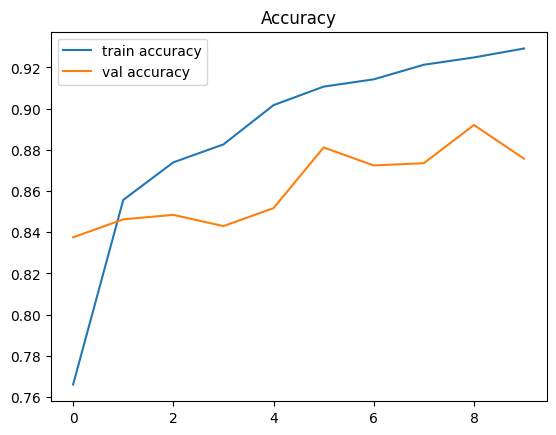

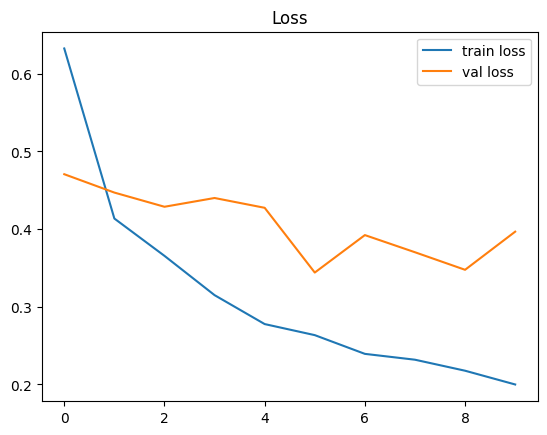

In [13]:
plt.plot(history.history['accuracy'], label='train accuracy')
plt.plot(history.history['val_accuracy'], label='val accuracy')
plt.legend()
plt.title("Accuracy")
plt.show()

plt.plot(history.history['loss'], label='train loss')
plt.plot(history.history['val_loss'], label='val loss')
plt.legend()
plt.title("Loss")
plt.show()

In [14]:
model.save("waste_classifier_mobilenetv2.h5")

In [15]:
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint

early_stop = EarlyStopping(
    monitor='val_loss',
    patience=3,
    restore_best_weights=True
)

checkpoint = ModelCheckpoint(
    "/content/drive/MyDrive/best_model.h5",
    monitor='val_accuracy',
    save_best_only=True,
    mode='max'
)

In [16]:
class_weight = {
    0:1,
    1:1,
    2:1,
    3:2   # trash boosted
}

In [17]:
history = model.fit(
    train_data,
    validation_data=val_data,
    epochs=20,
    callbacks=[early_stop, checkpoint],
    class_weight=class_weight
)

Epoch 1/20
115/115 ━━━━━━━━━━━━━━━━━━━━ 0s 450ms/step - accuracy: 0.9199 - loss: 0.2556

115/115 ━━━━━━━━━━━━━━━━━━━━ 72s 570ms/step - accuracy: 0.9229 - loss: 0.2403 - val_accuracy: 0.8713 - val_loss: 0.4059
Epoch 2/20
115/115 ━━━━━━━━━━━━━━━━━━━━ 0s 402ms/step - accuracy: 0.9235 - loss: 0.2378

115/115 ━━━━━━━━━━━━━━━━━━━━ 60s 523ms/step - accuracy: 0.9232 - loss: 0.2429 - val_accuracy: 0.8877 - val_loss: 0.3644
Epoch 3/20
115/115 ━━━━━━━━━━━━━━━━━━━━ 58s 504ms/step - accuracy: 0.9314 - loss: 0.2190 - val_accuracy: 0.8833 - val_loss: 0.3781
Epoch 4/20
115/115 ━━━━━━━━━━━━━━━━━━━━ 58s 506ms/step - accuracy: 0.9319 - loss: 0.2215 - val_accuracy: 0.8822 - val_loss: 0.3970
Epoch 5/20
115/115 ━━━━━━━━━━━━━━━━━━━━ 0s 403ms/step - accuracy: 0.9307 - loss: 0.2139

115/115 ━━━━━━━━━━━━━━━━━━━━ 61s 527ms/step - accuracy: 0.9284 - loss: 0.2212 - val_accuracy: 0.8909 - val_loss: 0.3363
Epoch 6/20
115/115 ━━━━━━━━━━━━━━━━━━━━ 0s 403ms/step - accuracy: 0.9363 - loss: 0.2097

115/115 ━━━━━━━━━━━━━━━━━━━━ 59s 518ms/step - accuracy: 0.9363 - loss: 0.2049 - val_accuracy: 0.8953 - val_loss: 0.3327
Epoch 7/20
115/115 ━━━━━━━━━━━━━━━━━━━━ 57s 495ms/step - accuracy: 0.9423 - loss: 0.1854 - val_accuracy: 0.8909 - val_loss: 0.3327
Epoch 8/20
115/115 ━━━━━━━━━━━━━━━━━━━━ 0s 409ms/step - accuracy: 0.9493 - loss: 0.1759

115/115 ━━━━━━━━━━━━━━━━━━━━ 60s 519ms/step - accuracy: 0.9483 - loss: 0.1771 - val_accuracy: 0.8997 - val_loss: 0.3728
Epoch 9/20
115/115 ━━━━━━━━━━━━━━━━━━━━ 60s 518ms/step - accuracy: 0.9455 - loss: 0.1710 - val_accuracy: 0.8888 - val_loss: 0.3549
Epoch 10/20
115/115 ━━━━━━━━━━━━━━━━━━━━ 60s 522ms/step - accuracy: 0.9480 - loss: 0.1657 - val_accuracy: 0.8986 - val_loss: 0.3366


In [18]:
base_model.trainable = True

# Freeze first few layers, train last layers
for layer in base_model.layers[:100]:
    layer.trainable = False

In [19]:
from tensorflow.keras.optimizers import Adam

model.compile(
    optimizer=Adam(learning_rate=0.0001),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

In [20]:
history_fine = model.fit(
    train_data,
    validation_data=val_data,
    epochs=10,
    callbacks=[early_stop, checkpoint],
    class_weight=class_weight
)

Epoch 1/10
115/115 ━━━━━━━━━━━━━━━━━━━━ 108s 717ms/step - accuracy: 0.8548 - loss: 0.5009 - val_accuracy: 0.7481 - val_loss: 1.2274
Epoch 2/10
115/115 ━━━━━━━━━━━━━━━━━━━━ 59s 515ms/step - accuracy: 0.9278 - loss: 0.2442 - val_accuracy: 0.7546 - val_loss: 1.1375
Epoch 3/10
115/115 ━━━━━━━━━━━━━━━━━━━━ 58s 503ms/step - accuracy: 0.9436 - loss: 0.1966 - val_accuracy: 0.7088 - val_loss: 1.6803


In [22]:
model.save("/content/drive/MyDrive/waste_classifier.keras")
model.save("/content/drive/MyDrive/waste_classifier.h5")

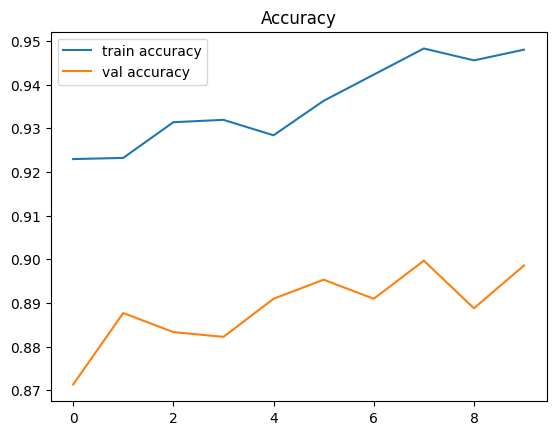

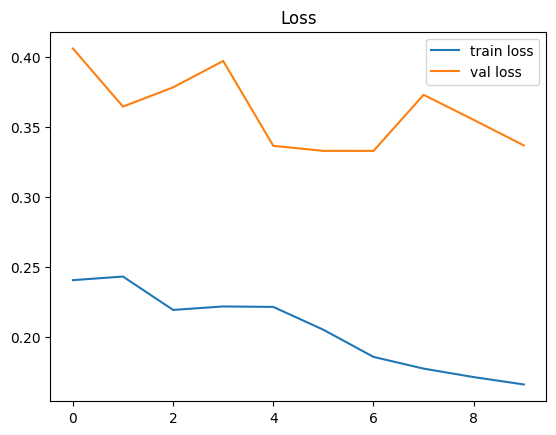

In [23]:
plt.plot(history.history['accuracy'], label='train accuracy')
plt.plot(history.history['val_accuracy'], label='val accuracy')
plt.legend()
plt.title("Accuracy")
plt.show()

plt.plot(history.history['loss'], label='train loss')
plt.plot(history.history['val_loss'], label='val loss')
plt.legend()
plt.title("Loss")
plt.show()

In [24]:
loss, accuracy = model.evaluate(val_data)

print("Validation Loss:", loss)
print("Validation Accuracy:", accuracy)

29/29 ━━━━━━━━━━━━━━━━━━━━ 12s 418ms/step - accuracy: 0.7317 - loss: 1.3201
Validation Loss: 1.320138692855835
Validation Accuracy: 0.7317339181900024


In [25]:
import numpy as np

predictions = model.predict(val_data)
y_pred = np.argmax(predictions, axis=1)

29/29 ━━━━━━━━━━━━━━━━━━━━ 21s 559ms/step


In [26]:
y_true = val_data.classes

In [27]:
from sklearn.metrics import classification_report

class_names = list(val_data.class_indices.keys())

print(classification_report(y_true, y_pred, target_names=class_names))

              precision    recall  f1-score   support

       metal       0.28      0.47      0.35       268
       paper       0.27      0.15      0.20       267
     plastic       0.27      0.27      0.27       264
       trash       0.12      0.06      0.08       118

    accuracy                           0.27       917
   macro avg       0.24      0.24      0.22       917
weighted avg       0.25      0.27      0.25       917



In [29]:
val_data.reset()

In [30]:
print("Class Indices:", val_data.class_indices)

Class Indices: {'metal': 0, 'paper': 1, 'plastic': 2, 'trash': 3}


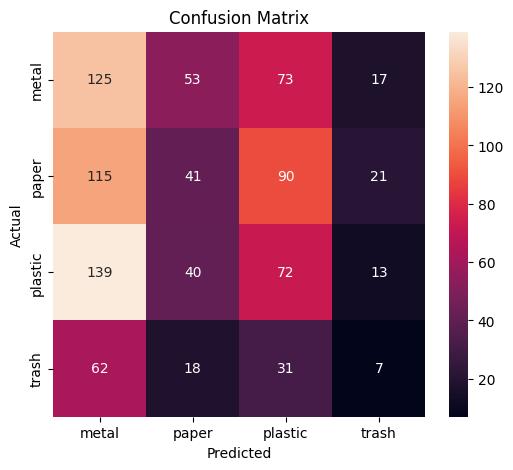

In [31]:
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

cm = confusion_matrix(y_true, y_pred)

plt.figure(figsize=(6,5))
sns.heatmap(cm, annot=True, fmt='d',
            xticklabels=class_names,
            yticklabels=class_names)

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")
plt.show()

In [32]:
val_data = train_datagen.flow_from_directory(
    dataset_path,
    target_size=(224, 224),
    batch_size=32,
    class_mode='categorical',
    subset='validation',
    shuffle=False   # ✅ ADD THIS
)

Found 917 images belonging to 4 classes.


In [33]:
val_data.reset()

In [34]:
predictions = model.predict(val_data)
y_pred = np.argmax(predictions, axis=1)
y_true = val_data.classes

29/29 ━━━━━━━━━━━━━━━━━━━━ 12s 399ms/step


In [35]:
from sklearn.metrics import classification_report
class_names = list(val_data.class_indices.keys())

print(classification_report(y_true, y_pred, target_names=class_names))

              precision    recall  f1-score   support

       metal       0.62      1.00      0.76       268
       paper       0.99      0.59      0.74       267
     plastic       0.89      0.86      0.87       264
       trash       0.72      0.42      0.53       118

    accuracy                           0.76       917
   macro avg       0.80      0.72      0.73       917
weighted avg       0.82      0.76      0.76       917



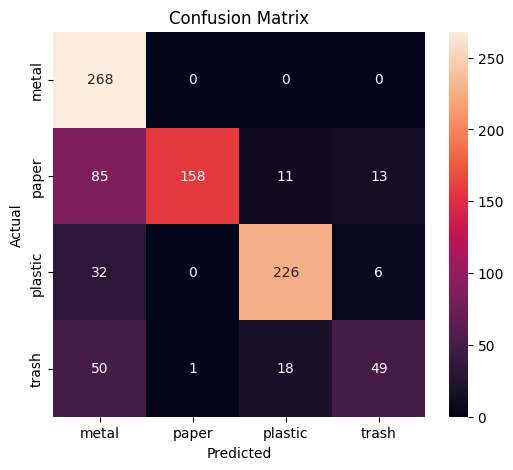

In [36]:
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

cm = confusion_matrix(y_true, y_pred)

plt.figure(figsize=(6,5))
sns.heatmap(cm, annot=True, fmt='d',
            xticklabels=class_names,
            yticklabels=class_names)

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")
plt.show()

In [37]:
class_weight = {
    0:1,
    1:1,
    2:1,
    3:3   # increase from 2 → 3
}

In [38]:
rotation_range=30,
zoom_range=0.3,
brightness_range=[0.7,1.3],

In [39]:
for layer in base_model.layers[:50]:
    layer.trainable = False

In [40]:
from tensorflow.keras.applications.mobilenet_v2 import preprocess_input

train_datagen = ImageDataGenerator(
    preprocessing_function=preprocess_input,
    validation_split=0.2,
    rotation_range=30,
    zoom_range=0.3,
    horizontal_flip=True,
    brightness_range=[0.7, 1.3],
    fill_mode='nearest'
)

In [41]:
train_data = train_datagen.flow_from_directory(
    dataset_path,
    target_size=(224, 224),
    batch_size=32,
    class_mode='categorical',
    subset='training'
)

val_data = train_datagen.flow_from_directory(
    dataset_path,
    target_size=(224, 224),
    batch_size=32,
    class_mode='categorical',
    subset='validation',
    shuffle=False   # VERY IMPORTANT
)

Found 3672 images belonging to 4 classes.
Found 917 images belonging to 4 classes.


In [42]:
class_weight = {
    0:1,
    1:1,
    2:1,
    3:3   # stronger boost
}

In [43]:
base_model = MobileNetV2(
    input_shape=(224, 224, 3),
    include_top=False,
    weights='imagenet'
)

base_model.trainable = False

x = base_model.output
x = layers.GlobalAveragePooling2D()(x)
x = layers.BatchNormalization()(x)
x = layers.Dense(128, activation='relu')(x)
x = layers.Dropout(0.5)(x)
output = layers.Dense(4, activation='softmax')(x)

model = models.Model(inputs=base_model.input, outputs=output)

In [44]:
from tensorflow.keras.optimizers import Adam

model.compile(
    optimizer=Adam(learning_rate=0.001),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

In [45]:
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau

early_stop = EarlyStopping(
    monitor='val_loss',
    patience=3,
    restore_best_weights=True
)

lr_reduce = ReduceLROnPlateau(
    monitor='val_loss',
    factor=0.3,
    patience=2,
    min_lr=1e-6
)

In [46]:
history = model.fit(
    train_data,
    validation_data=val_data,
    epochs=15,
    callbacks=[early_stop, lr_reduce],
    class_weight=class_weight
)

Epoch 1/15
115/115 ━━━━━━━━━━━━━━━━━━━━ 86s 663ms/step - accuracy: 0.7500 - loss: 0.9731 - val_accuracy: 0.8637 - val_loss: 0.4084 - learning_rate: 0.0010
Epoch 2/15
115/115 ━━━━━━━━━━━━━━━━━━━━ 62s 540ms/step - accuracy: 0.8538 - loss: 0.5671 - val_accuracy: 0.8800 - val_loss: 0.3539 - learning_rate: 0.0010
Epoch 3/15
115/115 ━━━━━━━━━━━━━━━━━━━━ 64s 559ms/step - accuracy: 0.8589 - loss: 0.5026 - val_accuracy: 0.8768 - val_loss: 0.3611 - learning_rate: 0.0010
Epoch 4/15
115/115 ━━━━━━━━━━━━━━━━━━━━ 62s 539ms/step - accuracy: 0.8791 - loss: 0.4284 - val_accuracy: 0.8768 - val_loss: 0.3442 - learning_rate: 0.0010
Epoch 5/15
115/115 ━━━━━━━━━━━━━━━━━━━━ 64s 556ms/step - accuracy: 0.8821 - loss: 0.3828 - val_accuracy: 0.8899 - val_loss: 0.3228 - learning_rate: 0.0010
Epoch 6/15
115/115 ━━━━━━━━━━━━━━━━━━━━ 62s 539ms/step - accuracy: 0.9011 - loss: 0.3361 - val_accuracy: 0.8899 - val_loss: 0.3699 - learning_rate: 0.0010
Epoch 7/15
115/115 ━━━━━━━━━━━━━━━━━━━━ 62s 544ms/step - accuracy: 0.9

In [47]:
base_model.trainable = True

for layer in base_model.layers[:50]:
    layer.trainable = False

In [48]:
model.compile(
    optimizer=Adam(learning_rate=0.00005),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

In [49]:
history_fine = model.fit(
    train_data,
    validation_data=val_data,
    epochs=10,
    callbacks=[early_stop, lr_reduce],
    class_weight=class_weight
)

Epoch 1/10
115/115 ━━━━━━━━━━━━━━━━━━━━ 125s 790ms/step - accuracy: 0.8094 - loss: 0.6708 - val_accuracy: 0.8702 - val_loss: 0.3858 - learning_rate: 5.0000e-05
Epoch 2/10
115/115 ━━━━━━━━━━━━━━━━━━━━ 64s 555ms/step - accuracy: 0.8614 - loss: 0.4735 - val_accuracy: 0.8790 - val_loss: 0.3969 - learning_rate: 5.0000e-05
Epoch 3/10
115/115 ━━━━━━━━━━━━━━━━━━━━ 66s 571ms/step - accuracy: 0.8875 - loss: 0.3846 - val_accuracy: 0.8909 - val_loss: 0.3702 - learning_rate: 1.5000e-05


In [50]:
loss, accuracy = model.evaluate(val_data)

print("Validation Loss:", loss)
print("Validation Accuracy:", accuracy)

29/29 ━━━━━━━━━━━━━━━━━━━━ 13s 462ms/step - accuracy: 0.8757 - loss: 0.4055
Validation Loss: 0.40551966428756714
Validation Accuracy: 0.8756815791130066


In [51]:
val_data.reset()

In [52]:
import numpy as np

predictions = model.predict(val_data)
y_pred = np.argmax(predictions, axis=1)

29/29 ━━━━━━━━━━━━━━━━━━━━ 23s 622ms/step


In [53]:
y_true = val_data.classes

In [54]:
from sklearn.metrics import classification_report

class_names = list(val_data.class_indices.keys())

print(classification_report(y_true, y_pred, target_names=class_names))

              precision    recall  f1-score   support

       metal       0.92      0.94      0.93       268
       paper       0.97      0.84      0.90       267
     plastic       0.84      0.93      0.88       264
       trash       0.72      0.73      0.72       118

    accuracy                           0.88       917
   macro avg       0.86      0.86      0.86       917
weighted avg       0.88      0.88      0.88       917



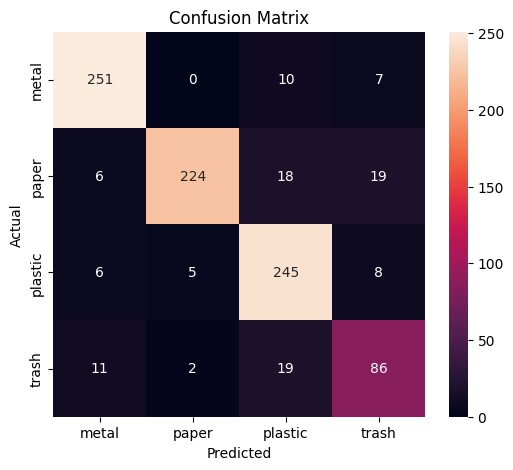

In [55]:
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

cm = confusion_matrix(y_true, y_pred)

plt.figure(figsize=(6,5))
sns.heatmap(cm, annot=True, fmt='d',
            xticklabels=class_names,
            yticklabels=class_names)

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")
plt.show()

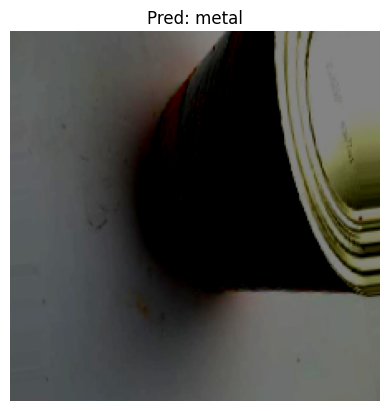

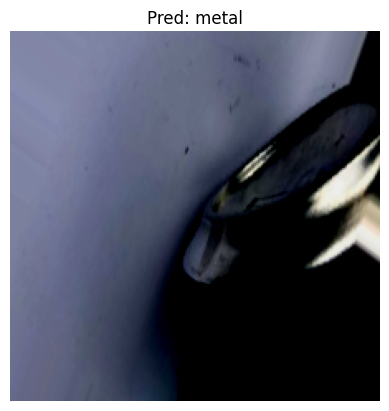

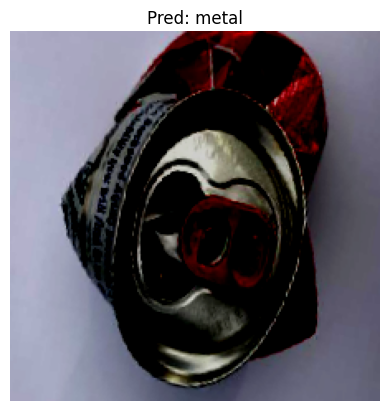

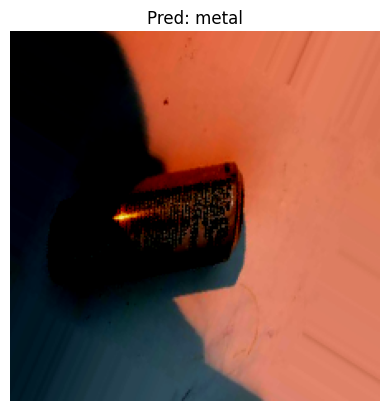

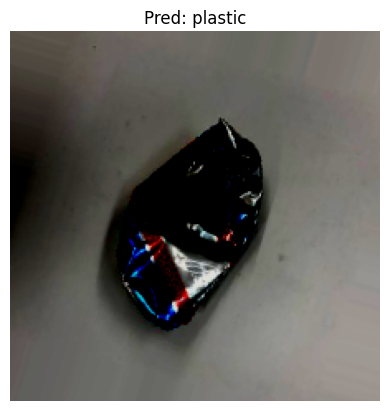

In [56]:
import matplotlib.pyplot as plt

images, labels = next(val_data)

for i in range(5):
    plt.imshow(images[i])
    plt.title("Pred: " + class_names[np.argmax(predictions[i])])
    plt.axis('off')
    plt.show()

In [57]:
model.save("/content/drive/MyDrive/final_model.keras")

In [58]:
model.save("/content/final_model.keras")

In [59]:
from google.colab import files
files.download("/content/final_model.keras")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>